# Wildfire Mapping with NASA FIRMS API

In this project, I explore recent wildfire detections in Europe using data from the NASA FIRMS API. The goal is to investigate where recent fires are located, how intense they are, and how detection confidence can be visualized on an interactive map.

## Workflow

The project follows a workflow from data download to interactive visualization.

1. Download recent wildfire detections from the NASA FIRMS API.

2. Inspect and clean the dataset by selecting the most relevant variables and converting the date column into a proper datetime format.

3. Analyze the wildfire detections by exploring confidence levels, fire intensity values and the strongest wildfire events.

4. Use reverse geocoding to identify the countries of the ten strongest wildfire detections.

5. Create a GeoDataFrame from the wildfire coordinates and visualize the detections on an interactive Folium map.

6. Save the cleaned dataset, analysis outputs and the final interactive wildfire map.

In [136]:
from pathlib import Path
from io import StringIO
from geopy.geocoders import Nominatim
import time
import requests
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt

#addition at the end (for url search)
from urllib.parse import quote


## Project folders

I use relative paths so that the notebook can be run from another computer as long as the repository structure stays the same.

In [137]:
PROJECT_ROOT = Path("..")

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"


## API settings

In this step, I define the main settings for the API request. I use recent VIIRS fire detections for Europe and set the time window to five days.

In [138]:
from config import MAP_KEY

SOURCE = "VIIRS_SNPP_NRT"
AREA = "-10,35,30,72"
DAYS = 5

RAW_FILE = RAW_DATA_DIR / "nasa_raw_.csv"
PROCESSED_FILE = PROCESSED_DATA_DIR / "nasa_cleaned_.csv"

## Online and offline mode

To make the workflow more reproducible, the notebook can either download fresh wildfire detections from the NASA FIRMS API or load a previously saved local dataset.

In [139]:
USE_API = True #False

## Download wildfire data from the NASA FIRMS API

In this step, I download recent wildfire detections from the NASA FIRMS API. The API returns the data as CSV text.

I use StringIO because the API response is not yet a saved CSV file on my computer. StringIO lets pandas read this text as if it were a file. After that, I save the data in data/raw so that the same dataset can be used again later.

If USE_API = False, the notebook skips the API request and loads the saved raw CSV file instead.

In [140]:
if USE_API:

    url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{MAP_KEY}/{SOURCE}/{AREA}/{DAYS}" #parameters which I defined before

    response = requests.get(url)

    if response.status_code == 200:

        df = pd.read_csv(StringIO(response.text)) #StringIO lets pandas read the API text like a CSV file.

        df.to_csv(RAW_FILE, index=False)

        print("Raw wildfire data downloaded and saved.")

    else:
        print(f"Request failed. Status code: {response.status_code}")

else: #offline mode
    
    df = pd.read_csv(RAW_FILE)

    print("Stored raw wildfire data loaded.")

Raw wildfire data downloaded and saved.


## Inspecting the raw wildfire data

Before cleaning the dataset, I first inspect the structure of the raw wildfire detections and check which variables are available.

In [141]:
df.head()

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,64.64723,24.42758,309.43,0.45,0.47,2026-05-16,13,N,VIIRS,n,2.0NRT,267.02,2.10,N
1,64.64786,24.42177,298.69,0.45,0.47,2026-05-16,13,N,VIIRS,n,2.0NRT,266.87,2.94,N
2,64.66596,21.28699,336.50,0.56,0.52,2026-05-16,13,N,VIIRS,n,2.0NRT,278.63,6.11,N
3,64.66645,21.27496,299.50,0.56,0.52,2026-05-16,13,N,VIIRS,n,2.0NRT,276.50,6.11,N
4,65.56187,22.22952,298.03,0.54,0.51,2026-05-16,13,N,VIIRS,n,2.0NRT,277.25,2.95,N


In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    1095 non-null   float64
 1   longitude   1095 non-null   float64
 2   bright_ti4  1095 non-null   float64
 3   scan        1095 non-null   float64
 4   track       1095 non-null   float64
 5   acq_date    1095 non-null   str    
 6   acq_time    1095 non-null   int64  
 7   satellite   1095 non-null   str    
 8   instrument  1095 non-null   str    
 9   confidence  1095 non-null   str    
 10  version     1095 non-null   str    
 11  bright_ti5  1095 non-null   float64
 12  frp         1095 non-null   float64
 13  daynight    1095 non-null   str    
dtypes: float64(7), int64(1), str(6)
memory usage: 145.6 KB


## Cleaning and preparing the data

Before creating maps and analyses, I clean and prepare the dataset by selecting the most relevant variables for the project. I keep the latitude and longitude coordinates for mapping, the acquisition date for temporal analysis, the confidence level to evaluate the reliability of detections, the FRP value to measure wildfire intensity, and the day or night information. The acquisition date is then converted into a proper datetime format to make later analysis and visualization easier.

In [143]:
columns = [
    "latitude",
    "longitude",
    "acq_date",
    "confidence",
    "frp",
    "daynight"
]

df = df[columns].copy()

df["acq_date"] = pd.to_datetime(df["acq_date"])

df.head()

,latitude,longitude,acq_date,confidence,frp,daynight
0,64.64723,24.42758,2026-05-16,n,2.10,N
1,64.64786,24.42177,2026-05-16,n,2.94,N
2,64.66596,21.28699,2026-05-16,n,6.11,N
3,64.66645,21.27496,2026-05-16,n,6.11,N
4,65.56187,22.22952,2026-05-16,n,2.95,N


## Saving the cleaned dataset

After cleaning the data, I save the processed wildfire detections as a separate CSV file. This keeps the raw API data unchanged and makes later analysis steps easier.

In [144]:
df.to_csv(PROCESSED_FILE, index=False)

print("Cleaned wildfire data saved.")

Cleaned wildfire data saved.


## Exploring the wildfire detections

Before creating the map, I explore some basic characteristics of the wildfire detections, such as the number of events, confidence levels, and fire intensity values.

In [145]:
print(f"Amount of wildfire detections: {len(df)}")

print("\nConfidence levels:")
print(df["confidence"].value_counts())

print("\nTop 5 highest FRP values:")
print(df["frp"].sort_values(ascending=False).head())

Amount of wildfire detections: 1095

Confidence levels:
confidence
n    1057
l      33
h       5
Name: count, dtype: int64

Top 5 highest FRP values:
228     123.47
1085     51.63
1044     43.54
460      31.58
1043     25.82
Name: frp, dtype: float64


## Strongest wildfire detections

To better understand the most intense detections, I sort the dataset by fire radiative power (frp).

In [146]:
top_fires = df.sort_values("frp", ascending=False).head(10)

top_fires

,latitude,longitude,acq_date,confidence,frp,daynight
228,45.21706,28.85383,2026-05-16,n,123.47,D
1085,37.98436,-8.81200,2026-05-19,n,51.63,D
1044,37.98475,-8.81614,2026-05-19,h,43.54,D
460,45.54865,11.96755,2026-05-17,n,31.58,D
1043,37.98182,-8.82495,2026-05-19,n,25.82,D
235,49.65331,28.38662,2026-05-16,n,22.79,D
1024,51.68835,15.97770,2026-05-19,n,19.56,D
19,52.84599,29.99024,2026-05-16,n,19.22,N
227,45.21222,28.85439,2026-05-16,n,18.12,D
747,65.76696,24.18045,2026-05-18,h,16.48,N


## Countries of the strongest wildfire detections

To better understand where the strongest wildfire detections occurred, I used reverse geocoding to assign a country to the ten highest FRP values.

As of 17 May 2026, eight out of the ten strongest wildfire detections in the dataset were located in Ukraine. This raises the question of whether some of these detections could be related to the ongoing war, although the dataset itself does not provide enough information to confirm the exact cause of the fires. More detailed analysis of this hotspot will be discussed in the final report.

In [147]:
top10 = df.nlargest(10, "frp").copy()

geolocator = Nominatim(user_agent="Country_top10_fire") # Create the geolocator for reverse geocoding

countries = []

# Find the country for each wildfire detection
for i, row in top10.iterrows():
    location = geolocator.reverse((row["latitude"], row["longitude"]), language="en")
    
    country = location.raw["address"].get("country")
    countries.append(country)
    
    time.sleep(1) # Avoid sending too many requests too quickly

top10["country"] = countries # Add countries to the created dataframe

top10[["latitude", "longitude", "frp", "confidence", "country"]]

,latitude,longitude,frp,confidence,country
228,45.21706,28.85383,123.47,n,Romania
1085,37.98436,-8.81200,51.63,n,Portugal
1044,37.98475,-8.81614,43.54,h,Portugal
460,45.54865,11.96755,31.58,n,Italy
1043,37.98182,-8.82495,25.82,n,Portugal
235,49.65331,28.38662,22.79,n,Ukraine
1024,51.68835,15.97770,19.56,n,Poland
19,52.84599,29.99024,19.22,n,Belarus
227,45.21222,28.85439,18.12,n,Romania
747,65.76696,24.18045,16.48,h,Finland


## Saving the strongest detections

I save the ten strongest wildfire detections as a separate output table. This makes it easier to use the result later in the report.

In [148]:
today = pd.Timestamp.today().strftime("%d%m%Y")

TOP_FIRES_FILE = OUTPUT_DIR / f"top_fire_detections_{today}.csv" # marked with today's date

top10.to_csv(TOP_FIRES_FILE, index=False)

print("Top wildfire detections saved.")

Top wildfire detections saved.


## Fire radiative power distribution

To better understand the intensity of the wildfire detections overall, I visualize the distribution of FRP values. Interpretations are in the report.

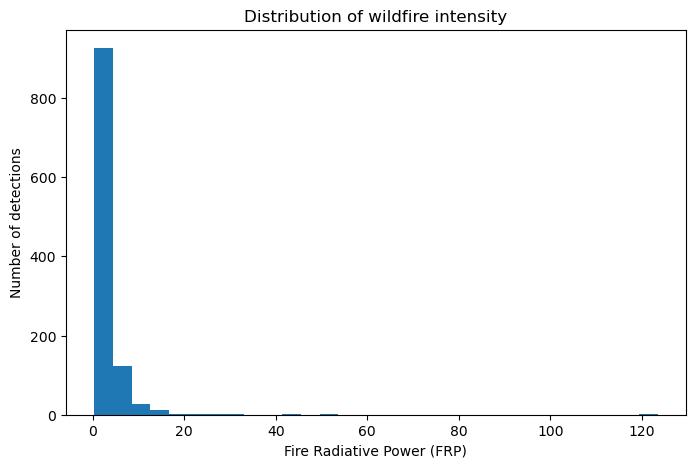

In [149]:
plt.figure(figsize=(8, 5))

plt.hist(df["frp"], bins=30)

plt.xlabel("Fire Radiative Power (FRP)")
plt.ylabel("Number of detections")
plt.title("Distribution of wildfire intensity")

plt.show()

## Creating a GeoDataFrame

To visualize the wildfire detections on a map, I convert the latitude and longitude coordinates into spatial point geometries using GeoPandas.

In [150]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

gdf.head()

,latitude,longitude,acq_date,confidence,frp,daynight,geometry
0,64.64723,24.42758,2026-05-16,n,2.10,N,POINT (24.42758 64.64723)
1,64.64786,24.42177,2026-05-16,n,2.94,N,POINT (24.42177 64.64786)
2,64.66596,21.28699,2026-05-16,n,6.11,N,POINT (21.28699 64.66596)
3,64.66645,21.27496,2026-05-16,n,6.11,N,POINT (21.27496 64.66645)
4,65.56187,22.22952,2026-05-16,n,2.95,N,POINT (22.22952 65.56187)


## Creating the interactive wildfire map

In this final visualization step, I create an interactive map with Folium. The wildfire detections are shown as circle markers. Larger markers represent stronger fires, while the popup displays additional information about each detection.

In [151]:
# Create the interactive Folium map
wildfire_map = folium.Map(
    location=[54, 15],
    zoom_start=4,
    tiles="CartoDB positron"
)

for _, row in gdf.iterrows():

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(row["frp"] / 10, 3),
        popup=(
            f"Date: {row['acq_date'].date()}<br>"
            f"Confidence: {row['confidence']}<br>"
            f"FRP: {row['frp']}"
        ),
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(wildfire_map)

# Add legend 
legend_html = """
<div style="
position: fixed;
bottom: 50px;
left: 50px;
width: 220px;
height: 120px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding: 10px;
">
<b>Map legend</b><br>
Circle size: higher FRP = stronger fire<br><br>
<span style="color:red;">●</span> Wildfire detection
</div>
"""

wildfire_map.get_root().html.add_child(folium.Element(legend_html))


wildfire_map

## Saving the interactive wildfire map

After creating the interactive wildfire map, I save it as an HTML file in the outputs folder. This makes it possible to reopen the map later in a web browser and include it in the final project results.

In [152]:
today = pd.Timestamp.today().strftime("%d%m%Y")

MAP_FILE = OUTPUT_DIR / f"wildfire_map_{today}.html"

wildfire_map.save(MAP_FILE)

print("Interactive wildfire map saved.")

Interactive wildfire map saved.
